# Llm deliberation pilot

This notebook belongs to the project's sequential measurement and validation programme. Read its result as evidence about behavioural validity, representation, comparator strength, timing, information matching, or mechanistic calibration as appropriate. Legacy H1/H_priv identifiers may remain inside code, saved paths, or frozen schemas for reproducibility; they are not the object being "found" by the current analysis.

**Repository framing.** The current paper separates target-specific representation from predictive privilege. A positive neural result is interpreted only after behavioural validity, control, comparator-strength, timing, and information-set checks.


# Latent reservations — Notebook 01
## LLM-Deliberation frozen-state pilot + all-layer probe

This notebook takes over from the completed infrastructure portion of Notebook 00.

Its job is to close the three gates that Notebook 00 intentionally left open:

1. validate one **real** LLM-Deliberation decision state end-to-end and replay it deterministically;
2. build a balanced **30-state** frozen-state pilot from multiple independent source trajectories;
3. capture pre-action activations at **all decoder layers**, run a matched text-only auditor, and compute the first diagnostic H1 estimate.

**Important scope rule:** this is still a pilot. The H1 estimate is a measurement/integration diagnostic, not the final paper result. The test split is trajectory-grouped, but with only five source trajectories its effective test sample is deliberately small.

**Output convention:** every artifact produced here lives under
`/workspace/latent-reservations/notebook_outputs/01_llm_deliberation_pilot/<RUN_ID>/`.
Notebook 00 outputs are read-only inputs and are never overwritten.

In [1]:
NOTEBOOK_BUILD = "latent-reservations-notebook01-pilot-run-all-v2"
print("=" * 76)
print(f"NOTEBOOK BUILD: {NOTEBOOK_BUILD}")
print("Frozen-state pilot + all-layer probe")
print("=" * 76)

NOTEBOOK BUILD: latent-reservations-notebook01-pilot-run-all-v2
Frozen-state pilot + all-layer probe


## 0. Ensure notebook dependencies

This is intentionally executable in a fresh kernel. It does not reinstall PyTorch if PyTorch is already available, but it does ensure all Python packages used by this notebook are installed from inside the notebook.

In [2]:
import importlib.util, subprocess, sys

if importlib.util.find_spec("torch") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "torch"], check=True)

subprocess.run([
    sys.executable, "-m", "pip", "install",
    "transformers>=4.45,<5",
    "accelerate>=0.30,<2",
    "safetensors>=0.4",
    "numpy<2",
    "pandas>=2,<3",
    "scipy>=1.12,<2",
    "scikit-learn>=1.4,<2",
    "matplotlib>=3.8,<4",
    "tqdm>=4.66",
], check=True)
print("Notebook 01 dependencies ready.")

Notebook 01 dependencies ready.


## 1. Paths and isolated run directory


In [3]:
from __future__ import annotations

import csv
import hashlib
import json
import os
import random
import re
import runpy
import shlex
import shutil
import subprocess
import sys
import time
from dataclasses import dataclass, asdict
from datetime import datetime, timezone
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd

PROJECT_ROOT = Path(os.environ.get("LR_PROJECT_ROOT", "/workspace/latent-reservations")).expanduser().resolve()
NOTEBOOK_SLUG = "01_llm_deliberation_pilot"
RUN_ID = os.environ.get("LR_RUN_ID", datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ"))
NOTEBOOK_OUTPUT_BASE = PROJECT_ROOT / "notebook_outputs" / NOTEBOOK_SLUG
RUN_OUTPUT_DIR = NOTEBOOK_OUTPUT_BASE / RUN_ID
MANIFEST_DIR = RUN_OUTPUT_DIR / "manifests"
DATA_DIR = RUN_OUTPUT_DIR / "data"
RESULTS_DIR = RUN_OUTPUT_DIR / "results"
HF_CACHE_DIR = Path(os.environ.get("HF_HOME", "/workspace/.cache/huggingface")).expanduser().resolve()
UPSTREAM_DIR = PROJECT_ROOT / "vendor" / "llm-deliberation"
NB00_BASE = PROJECT_ROOT / "notebook_outputs" / "00_llm_deliberation_bootstrap"

for p in [
    MANIFEST_DIR,
    DATA_DIR / "source_histories",
    DATA_DIR / "source_game",
    DATA_DIR / "states",
    DATA_DIR / "branches",
    DATA_DIR / "activations",
    DATA_DIR / "derived",
    RESULTS_DIR / "tables",
    RESULTS_DIR / "figures",
]:
    p.mkdir(parents=True, exist_ok=True)
NOTEBOOK_OUTPUT_BASE.mkdir(parents=True, exist_ok=True)

latest_pointer = {
    "notebook_slug": NOTEBOOK_SLUG,
    "run_id": RUN_ID,
    "run_output_dir": str(RUN_OUTPUT_DIR),
    "updated_at_utc": datetime.now(timezone.utc).isoformat(),
}
(NOTEBOOK_OUTPUT_BASE / "latest_run.json").write_text(json.dumps(latest_pointer, indent=2))

print(f"RUN_OUTPUT_DIR = {RUN_OUTPUT_DIR}")


RUN_OUTPUT_DIR = /workspace/latent-reservations/notebook_outputs/01_llm_deliberation_pilot/20260813T235230Z


## 2. Import and verify Notebook 00's completed bootstrap gates

Notebook 00 remains immutable. This notebook reads its `latest_run.json`, `measurement_gate.json`, and manifest, then copies only the source negotiation history needed for the pilot into Notebook 01's own output directory.

In [4]:
nb00_latest_path = NB00_BASE / "latest_run.json"
if not nb00_latest_path.exists():
    raise FileNotFoundError(f"Notebook 00 latest-run pointer not found: {nb00_latest_path}")

nb00_latest = json.loads(nb00_latest_path.read_text())
NB00_RUN_DIR = Path(nb00_latest["run_output_dir"])
nb00_gate_path = NB00_RUN_DIR / "results" / "tables" / "measurement_gate.json"
nb00_manifest_path = NB00_RUN_DIR / "manifests" / "upstream_repositories.yaml"
nb00_hook_path = NB00_RUN_DIR / "manifests" / "subject_model_smoke.json"

nb00_gate = json.loads(nb00_gate_path.read_text())
nb00_manifest = json.loads(nb00_manifest_path.read_text())["llm_deliberation"]
nb00_hook = json.loads(nb00_hook_path.read_text())

required_true = [
    "output_isolated_by_notebook",
    "environment_recorded",
    "upstream_repo_present",
    "upstream_commit_recorded",
    "native_smoke_passed",
    "subject_model_smoke_passed",
    "immutable_state_schema_ready",
    "matched_information_assertion_ready",
    "pilot_ledger_ready",
]
missing = [k for k in required_true if not nb00_gate.get(k, False)]
if missing:
    raise RuntimeError(f"Notebook 00 bootstrap is not ready; failed gates: {missing}")

SUBJECT_MODEL = nb00_manifest["subject_model"]
SUBJECT_REVISION = nb00_manifest.get("subject_revision", "main")
UPSTREAM_COMMIT = nb00_manifest["commit"]
AGENTS_NUM = int(nb00_manifest["agents_num"])
ISSUES_NUM = int(nb00_manifest["issues_num"])
ROUNDS_NUM = int(nb00_manifest["rounds_num"])
NATIVE_TEMPERATURE = float(nb00_manifest.get("native_temperature", 0.7))
WINDOW_SIZE = AGENTS_NUM

actual_commit = subprocess.check_output(
    ["git", "rev-parse", "HEAD"], cwd=UPSTREAM_DIR, text=True
).strip()
if actual_commit != UPSTREAM_COMMIT:
    raise RuntimeError(f"Upstream commit drift: {actual_commit} != Notebook00 {UPSTREAM_COMMIT}")

# Runtime-generated/untracked files are allowed. We only block modifications that could
# change prompts, scoring, parsing, game configuration, or generation behavior.
def git_lines(args):
    out = subprocess.check_output(["git", *args], cwd=UPSTREAM_DIR, text=True).strip()
    return [line for line in out.splitlines() if line.strip()]

unstaged_tracked = git_lines(["diff", "--name-only"])
staged_tracked = git_lines(["diff", "--cached", "--name-only"])
untracked = git_lines(["ls-files", "--others", "--exclude-standard"])
tracked_changed = sorted(set(unstaged_tracked + staged_tracked))

def affects_experiment(path: str) -> bool:
    return path.endswith(".py") or path.startswith("games_descriptions/")

critical_tracked_changes = [p for p in tracked_changed if affects_experiment(p)]
noncritical_tracked_changes = [p for p in tracked_changed if p not in critical_tracked_changes]

worktree_record = {
    "upstream_commit": actual_commit,
    "expected_commit": UPSTREAM_COMMIT,
    "tracked_changed": tracked_changed,
    "critical_tracked_changes": critical_tracked_changes,
    "noncritical_tracked_changes": noncritical_tracked_changes,
    "untracked": untracked,
    "policy": "commit must match; tracked .py or games_descriptions changes block; other tracked/untracked files are recorded but do not block",
}
worktree_record_path = MANIFEST_DIR / "upstream_worktree_status.json"
worktree_record_path.write_text(json.dumps(worktree_record, indent=2))

if critical_tracked_changes:
    diff_text = subprocess.check_output(
        ["git", "diff", "--", *critical_tracked_changes],
        cwd=UPSTREAM_DIR,
        text=True,
        stderr=subprocess.STDOUT,
    )
    raise RuntimeError(
        "Pinned upstream commit matches, but experiment-relevant tracked files were modified:\n"
        + "\n".join(f"  - {p}" for p in critical_tracked_changes)
        + "\n\nDiff tail:\n"
        + diff_text[-12000:]
    )

if noncritical_tracked_changes:
    print("WARNING: non-experiment tracked upstream files differ from HEAD; recorded for provenance:")
    for p in noncritical_tracked_changes:
        print("  ", p)
if untracked:
    print(f"INFO: {len(untracked)} untracked upstream runtime file(s) recorded and allowed.")
    for p in untracked[:20]:
        print("  ", p)
    if len(untracked) > 20:
        print(f"  ... plus {len(untracked) - 20} more")

# Copy Notebook 00's successful native history into Notebook 01 as source trajectory 000.
nb00_game_dir = Path(nb00_manifest["auto_configured_game_dir"])
history_candidates = sorted((nb00_game_dir / "output").glob("*/history*.json"), key=lambda p: p.stat().st_mtime)
if not history_candidates:
    raise FileNotFoundError(f"No Notebook 00 history JSON found below {nb00_game_dir / 'output'}")
nb00_history = history_candidates[-1]
trajectory0 = DATA_DIR / "source_histories" / "trajectory_000_nb00.json"
shutil.copy2(nb00_history, trajectory0)

print(json.dumps({
    "notebook00_run": str(NB00_RUN_DIR),
    "subject_model": SUBJECT_MODEL,
    "upstream_commit": UPSTREAM_COMMIT,
    "tracked_changes": tracked_changed,
    "untracked_count": len(untracked),
    "worktree_record": str(worktree_record_path),
    "copied_history": str(trajectory0),
}, indent=2))


INFO: 6 untracked upstream runtime file(s) recorded and allowed.
   __pycache__/agent.cpython-312.pyc
   __pycache__/initial_prompts.cpython-312.pyc
   __pycache__/prompt_utils.cpython-312.pyc
   __pycache__/rounds.cpython-312.pyc
   __pycache__/save_utils.cpython-312.pyc
   __pycache__/utils.cpython-312.pyc
{
  "notebook00_run": "/workspace/latent-reservations/notebook_outputs/00_llm_deliberation_bootstrap/20260813T212827Z",
  "subject_model": "Qwen/Qwen2.5-7B-Instruct",
  "upstream_commit": "78e11e04ba89b9d888cb006f57bad696584a32f1",
  "tracked_changes": [],
  "untracked_count": 6,
  "worktree_record": "/workspace/latent-reservations/notebook_outputs/01_llm_deliberation_pilot/20260813T235230Z/manifests/upstream_worktree_status.json",
  "copied_history": "/workspace/latent-reservations/notebook_outputs/01_llm_deliberation_pilot/20260813T235230Z/data/source_histories/trajectory_000_nb00.json"
}


## 3. Create Notebook 01's own source-game copy

All additional native simulations write inside this notebook's run folder. The shared upstream checkout is never modified.

In [5]:
SOURCE_GAME_DIR = DATA_DIR / "source_game" / f"base_{UPSTREAM_COMMIT[:12]}"
if not SOURCE_GAME_DIR.exists():
    shutil.copytree(UPSTREAM_DIR / "games_descriptions" / "base", SOURCE_GAME_DIR)

source_config = SOURCE_GAME_DIR / "config.txt"
lines = [line for line in source_config.read_text().splitlines() if line.strip()]
patched = []
for line in lines:
    parts = [p.strip() for p in line.split(",")]
    if len(parts) != 5:
        raise ValueError(f"Unexpected config row: {line!r}")
    parts[4] = f"hf_{SUBJECT_MODEL}"
    patched.append(",".join(parts))
source_config.write_text("\n".join(patched) + "\n")

if len(patched) != AGENTS_NUM:
    raise AssertionError(f"Expected {AGENTS_NUM} agents, found {len(patched)}")

print(source_config.read_text())

Mayor,mayor,player,cooperative,hf_Qwen/Qwen2.5-7B-Instruct
Other cities,other_cities,player,cooperative,hf_Qwen/Qwen2.5-7B-Instruct
Local Labour Union,union,player,cooperative,hf_Qwen/Qwen2.5-7B-Instruct
SportCo,SportCo,p1,greedy,hf_Qwen/Qwen2.5-7B-Instruct
Department of Tourism,DoT,p2,greedy,hf_Qwen/Qwen2.5-7B-Instruct
Environmental League,enviroment,player,greedy,hf_Qwen/Qwen2.5-7B-Instruct



## 4. Generate independent source trajectories

The existing Notebook 00 trajectory is trajectory 000. By default this notebook generates **four additional native trajectories**, giving five independent source-trajectory groups.

Each new trajectory uses a project-owned seeded wrapper around the pinned upstream `main.py`. The wrapper seeds Python, NumPy, and PyTorch before executing upstream code; upstream itself is not edited.

Override with `LR_PILOT_NEW_TRAJECTORIES`, but the default five-total design is what the grouped pilot expects.

In [7]:
N_NEW = int(os.environ.get("LR_PILOT_NEW_TRAJECTORIES", "4"))
SOURCE_SEED_BASE = int(os.environ.get("LR_SOURCE_SEED_BASE", "17011"))
SOURCE_SEEDS = [SOURCE_SEED_BASE + 1009 * i for i in range(1, N_NEW + 1)]

seed_wrapper = RUN_OUTPUT_DIR / "seeded_upstream_runner.py"
seed_wrapper.write_text(r"""import os, random, runpy, sys
import numpy as np
import torch
seed = int(os.environ["LR_SOURCE_SEED"])
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
upstream_dir = os.environ["LR_UPSTREAM_DIR"]
os.chdir(upstream_dir)
sys.path.insert(0, upstream_dir)
runpy.run_path(os.path.join(upstream_dir, "main.py"), run_name="__main__")
""")

def run_source_trajectory(idx: int, seed: int) -> Path:
    dest = DATA_DIR / "source_histories" / f"trajectory_{idx:03d}_seed{seed}.json"
    if dest.exists():
        print(f"trajectory {idx:03d}: using existing {dest.name}")
        return dest

    exp_name = f"pilot_source_{RUN_ID}_{idx:03d}_seed{seed}"
    cmd = [
        sys.executable, str(seed_wrapper),
        "--exp_name", exp_name,
        "--agents_num", str(AGENTS_NUM),
        "--issues_num", str(ISSUES_NUM),
        "--window_size", str(WINDOW_SIZE),
        "--game_dir", str(SOURCE_GAME_DIR),
        "--rounds_num", str(ROUNDS_NUM),
        "--temp", str(NATIVE_TEMPERATURE),
        "--hf_home", str(HF_CACHE_DIR),
    ]
    env = os.environ.copy()
    env["LR_SOURCE_SEED"] = str(seed)
    env["LR_UPSTREAM_DIR"] = str(UPSTREAM_DIR)
    log_path = MANIFEST_DIR / f"source_trajectory_{idx:03d}_seed{seed}.log"
    record_path = MANIFEST_DIR / f"source_trajectory_{idx:03d}_seed{seed}.json"

    print(f"trajectory {idx:03d}: seed={seed} starting")
    started = time.time()
    with log_path.open("w") as log:
        proc = subprocess.run(cmd, env=env, stdout=log, stderr=subprocess.STDOUT, text=True, timeout=21600)
    record = {
        "trajectory_index": idx,
        "seed": seed,
        "cmd": cmd,
        "returncode": proc.returncode,
        "elapsed_s": round(time.time() - started, 3),
        "log": str(log_path),
    }
    record_path.write_text(json.dumps(record, indent=2))
    if proc.returncode != 0:
        tail = log_path.read_text(errors="replace")[-12000:]
        raise RuntimeError(f"Source trajectory {idx} failed.\n\n{tail}")

    run_dir = SOURCE_GAME_DIR / "output" / exp_name
    histories = sorted(run_dir.glob("history*.json"), key=lambda p: p.stat().st_mtime)
    if not histories:
        raise FileNotFoundError(f"Successful upstream process produced no history under {run_dir}")
    shutil.copy2(histories[-1], dest)
    print(f"trajectory {idx:03d}: complete -> {dest.name} ({record['elapsed_s']}s)")
    return dest

trajectory_paths = [trajectory0]
for i, seed in enumerate(SOURCE_SEEDS, start=1):
    trajectory_paths.append(run_source_trajectory(i, seed))

if len(trajectory_paths) < 5:
    raise RuntimeError(f"Pilot expects at least 5 source trajectories; found {len(trajectory_paths)}")
print(f"Source trajectories ready: {len(trajectory_paths)}")


trajectory 001: seed=18020 starting
trajectory 001: complete -> trajectory_001_seed18020.json (430.094s)
trajectory 002: seed=19029 starting
trajectory 002: complete -> trajectory_002_seed19029.json (453.355s)
trajectory 003: seed=20038 starting
trajectory 003: complete -> trajectory_003_seed20038.json (452.184s)
trajectory 004: seed=21047 starting
trajectory 004: complete -> trajectory_004_seed21047.json (440.221s)
Source trajectories ready: 5


## 5. Reconstruct exact subject observations and score functions

For the pinned Hugging Face path, upstream constructs the model input from:

`InitialPrompt.return_initial_prompt() + logged round prompt`

and then applies the model's chat template. We reconstruct that exact raw subject text using the pinned upstream classes and verify every logged public deal against the copied private score tables.

In [8]:
sys.path.insert(0, str(UPSTREAM_DIR))
from initial_prompts import InitialPrompt
from utils import load_setup

agents, initial_deal, role_to_agent_names = load_setup(str(SOURCE_GAME_DIR), AGENTS_NUM)

# Parse private score tables.
score_tables: dict[str, dict[str, Any]] = {}
for agent_name, cfg in agents.items():
    score_path = SOURCE_GAME_DIR / "scores_files" / f"{cfg['file_name']}.txt"
    slines = [line.strip() for line in score_path.read_text().splitlines() if line.strip()]
    score_tables[agent_name] = {
        "issues": {
            chr(ord("A") + i): [int(x.strip()) for x in slines[i].split(",")]
            for i in range(len(slines) - 1)
        },
        "threshold": float(slines[-1]),
        "score_file": str(score_path),
    }

initial_prompts = {}
for agent_name, cfg in agents.items():
    ip = InitialPrompt(
        str(SOURCE_GAME_DIR),
        agent_name,
        cfg["file_name"],
        role_to_agent_names["p1"],
        role_to_agent_names["p2"],
        num_issues=ISSUES_NUM,
        num_agents=AGENTS_NUM,
        incentive=cfg["incentive"],
    )
    initial_prompts[agent_name] = ip.return_initial_prompt()

ISSUES = [chr(ord("A") + i) for i in range(ISSUES_NUM)]

def parse_deal(text: str) -> dict[str, int] | None:
    if not text:
        return None
    blocks = re.findall(r"<DEAL>(.*?)</DEAL>", text, flags=re.IGNORECASE | re.DOTALL)
    candidates = list(reversed(blocks)) + [text]
    for candidate in candidates:
        matches = re.findall(r"\b([A-Z])\s*([1-9]\d*)\b", candidate, flags=re.IGNORECASE)
        found = {}
        for issue, number in matches:
            issue = issue.upper()
            if issue in ISSUES:
                found[issue] = int(number)
        if set(found) == set(ISSUES):
            return {k: found[k] for k in ISSUES}
    return None

def deal_is_legal(agent_name: str, deal: dict[str, int] | None) -> bool:
    if deal is None or set(deal) != set(ISSUES):
        return False
    table = score_tables[agent_name]["issues"]
    return all(1 <= deal[issue] <= len(table[issue]) for issue in ISSUES)

def score_deal(agent_name: str, deal: dict[str, int]) -> float:
    if not deal_is_legal(agent_name, deal):
        raise ValueError(f"Illegal deal for {agent_name}: {deal}")
    table = score_tables[agent_name]["issues"]
    return float(sum(table[issue][deal[issue] - 1] for issue in ISSUES))

def canonical_deal(deal: dict[str, int]) -> str:
    return ", ".join(f"{issue}{deal[issue]}" for issue in ISSUES)

def sha256_text(text: str) -> str:
    return hashlib.sha256(text.encode("utf-8")).hexdigest()

candidate_rows = []
invalid_source_records = []
trajectory_records = {}
for trajectory_id, path in enumerate(trajectory_paths):
    hist = json.loads(path.read_text())
    rounds = hist["rounds"]
    trajectory_records[trajectory_id] = rounds
    # Exclude kickoff record 0 and final p1 consolidation record -1.
    for round_index, rec in list(enumerate(rounds))[1:-1]:
        agent_name = rec["agent"]
        logged_deal = parse_deal(rec.get("public_answer", ""))
        if not deal_is_legal(agent_name, logged_deal):
            invalid_source_records.append({
                "trajectory_id": trajectory_id,
                "round_index": round_index,
                "agent": agent_name,
                "public_answer": rec.get("public_answer", ""),
            })
            continue
        exact_subject_text = initial_prompts[agent_name] + rec["prompt"]
        candidate_rows.append({
            "trajectory_id": f"trajectory_{trajectory_id:03d}",
            "source_history": str(path),
            "round_index": round_index,
            "agent": agent_name,
            "role": agents[agent_name]["role"],
            "incentive": agents[agent_name]["incentive"],
            "initial_prompt": initial_prompts[agent_name],
            "round_prompt": rec["prompt"],
            "exact_subject_text": exact_subject_text,
            "observation_hash": sha256_text(exact_subject_text),
            "logged_public_answer": rec.get("public_answer", ""),
            "logged_deal": logged_deal,
            "logged_score": score_deal(agent_name, logged_deal),
            "threshold": score_tables[agent_name]["threshold"],
        })

print(f"Candidate decision states: {len(candidate_rows)}")
print(f"All logged candidate actions legal: {all(deal_is_legal(r['agent'], r['logged_deal']) for r in candidate_rows)}")

Candidate decision states: 120
All logged candidate actions legal: True


## 6. Select and serialize the 30-state balanced pilot

Selection is balanced by trajectory and agent: **one frozen state per agent per trajectory**. With five trajectories and six agents this yields exactly 30 states.

In [9]:
@dataclass(frozen=True)
class FrozenDecisionState:
    state_id: str
    trajectory_id: str
    source_history: str
    round_index: int
    agent: str
    role: str
    incentive: str
    initial_prompt: str
    round_prompt: str
    exact_subject_text: str
    observation_hash: str
    logged_public_answer: str
    logged_deal: dict[str, int]
    logged_score: float
    threshold: float
    score_table: dict[str, list[int]]
    upstream_commit: str
    subject_model: str


def state_hash(state: FrozenDecisionState) -> str:
    payload = json.dumps(asdict(state), sort_keys=True, ensure_ascii=False, separators=(",", ":"))
    return hashlib.sha256(payload.encode()).hexdigest()

def save_state(state: FrozenDecisionState) -> Path:
    payload = asdict(state)
    payload["parent_snapshot_hash"] = state_hash(state)
    path = DATA_DIR / "states" / f"{state.state_id}.json"
    path.write_text(json.dumps(payload, indent=2, ensure_ascii=False))
    return path

def load_state(path: Path) -> FrozenDecisionState:
    payload = json.loads(path.read_text())
    expected = payload.pop("parent_snapshot_hash")
    state = FrozenDecisionState(**payload)
    actual = state_hash(state)
    if actual != expected:
        raise ValueError(f"State hash mismatch: {actual} != {expected}")
    if sha256_text(state.exact_subject_text) != state.observation_hash:
        raise ValueError("Observation hash mismatch")
    return state

selected = []
by_trajectory = {}
for row in candidate_rows:
    by_trajectory.setdefault(row["trajectory_id"], []).append(row)

for t_idx, trajectory_id in enumerate(sorted(by_trajectory)):
    rows = by_trajectory[trajectory_id]
    for agent_name in sorted(agents):
        options = [r for r in rows if r["agent"] == agent_name]
        if not options:
            raise RuntimeError(f"No candidate state for {agent_name} in {trajectory_id}")
        # Rotate which occurrence we take across trajectories to cover different negotiation stages.
        pick = options[t_idx % len(options)]
        selected.append(pick)

if len(selected) != 30:
    raise AssertionError(f"Expected 30 selected states, found {len(selected)}")

states = []
for i, row in enumerate(selected):
    state = FrozenDecisionState(
        state_id=f"ld_{i:03d}_{row['trajectory_id']}_{re.sub(r'[^A-Za-z0-9]+', '_', row['agent']).strip('_').lower()}",
        trajectory_id=row["trajectory_id"],
        source_history=row["source_history"],
        round_index=int(row["round_index"]),
        agent=row["agent"],
        role=row["role"],
        incentive=row["incentive"],
        initial_prompt=row["initial_prompt"],
        round_prompt=row["round_prompt"],
        exact_subject_text=row["exact_subject_text"],
        observation_hash=row["observation_hash"],
        logged_public_answer=row["logged_public_answer"],
        logged_deal=row["logged_deal"],
        logged_score=float(row["logged_score"]),
        threshold=float(row["threshold"]),
        score_table=score_tables[row["agent"]]["issues"],
        upstream_commit=UPSTREAM_COMMIT,
        subject_model=SUBJECT_MODEL,
    )
    path = save_state(state)
    loaded = load_state(path)
    assert loaded == state
    states.append(state)


balance = pd.DataFrame([{"trajectory": s.trajectory_id, "agent": s.agent} for s in states])
print(pd.crosstab(balance["trajectory"], balance["agent"]))
print(f"Frozen states serialized and round-trip verified: {len(states)}")


agent           Department of Tourism  Environmental League  \
trajectory                                                    
trajectory_000                      1                     1   
trajectory_001                      1                     1   
trajectory_002                      1                     1   
trajectory_003                      1                     1   
trajectory_004                      1                     1   

agent           Local Labour Union  Mayor  Other cities  SportCo  
trajectory                                                        
trajectory_000                   1      1             1        1  
trajectory_001                   1      1             1        1  
trajectory_002                   1      1             1        1  
trajectory_003                   1      1             1        1  
trajectory_004                   1      1             1        1  
Frozen states serialized and round-trip verified: 30


## 7. Load the subject model and define exact pre-action all-layer capture

For every action branch the notebook applies the tokenizer's chat template to the exact reconstructed `initial_prompt + round_prompt`, then captures the residual-stream output at the final prompt token for **every decoder layer during the initial forward pass only**.

In [10]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from safetensors.torch import save_file, load_file

if not torch.cuda.is_available():
    raise RuntimeError("CUDA is required for Notebook 01.")

tokenizer = AutoTokenizer.from_pretrained(SUBJECT_MODEL, revision=SUBJECT_REVISION, cache_dir=str(HF_CACHE_DIR))
model = AutoModelForCausalLM.from_pretrained(
    SUBJECT_MODEL,
    revision=SUBJECT_REVISION,
    cache_dir=str(HF_CACHE_DIR),
    dtype=torch.bfloat16,
    device_map={"": 0},
    low_cpu_mem_usage=True,
)
model.eval()


def find_decoder_layers(model):
    candidates = [
        ("model.layers", lambda m: getattr(getattr(m, "model", None), "layers", None)),
        ("transformer.h", lambda m: getattr(getattr(m, "transformer", None), "h", None)),
        ("gpt_neox.layers", lambda m: getattr(getattr(m, "gpt_neox", None), "layers", None)),
        ("model.decoder.layers", lambda m: getattr(getattr(getattr(m, "model", None), "decoder", None), "layers", None)),
    ]
    for name, getter in candidates:
        layers = getter(model)
        if layers is not None and len(layers) > 0:
            return name, layers
    raise TypeError("Could not locate decoder layers for this architecture.")

layer_path, layers = find_decoder_layers(model)
N_LAYERS = len(layers)
HIDDEN_SIZE = int(model.config.hidden_size)
print({"layer_path": layer_path, "layers": N_LAYERS, "hidden_size": HIDDEN_SIZE})


def render_native_subject_input(state: FrozenDecisionState) -> str:
    # Matches the upstream HF branch: one user message containing initial_prompt + round_prompt.
    return tokenizer.apply_chat_template(
        [{"role": "user", "content": state.exact_subject_text}],
        tokenize=False,
        add_generation_prompt=True,
    )


def generate_action(state: FrozenDecisionState, *, capture_all_layers: bool, max_new_tokens: int = 512):
    rendered = render_native_subject_input(state)
    inputs = tokenizer(rendered, return_tensors="pt").to(model.device)
    captured = [None] * N_LAYERS
    captured_seq_len = [None] * N_LAYERS
    done = [False] * N_LAYERS
    handles = []

    if capture_all_layers:
        for layer_idx, layer in enumerate(layers):
            def make_hook(idx):
                def hook(_module, _inputs, output):
                    if done[idx]:
                        return
                    hidden = output[0] if isinstance(output, tuple) else output
                    if getattr(hidden, "ndim", 0) == 3:
                        captured[idx] = hidden[:, -1, :].detach().to(dtype=torch.float16, device="cpu").squeeze(0).clone()
                        captured_seq_len[idx] = int(hidden.shape[1])
                        done[idx] = True
                return hook
            handles.append(layer.register_forward_hook(make_hook(layer_idx)))

    try:
        with torch.no_grad():
            generated = model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                use_cache=True,
                pad_token_id=tokenizer.eos_token_id,
            )
    finally:
        for handle in handles:
            handle.remove()

    new_tokens = generated[0, inputs["input_ids"].shape[1]:]
    raw = tokenizer.decode(new_tokens, skip_special_tokens=True)
    deal = parse_deal(raw)
    legal = deal_is_legal(state.agent, deal)
    score = score_deal(state.agent, deal) if legal else None

    activation = None
    if capture_all_layers:
        if not all(done) or any(x is None for x in captured):
            missing = [i for i, x in enumerate(captured) if x is None]
            raise RuntimeError(f"Missing activation captures at layers: {missing}")
        prompt_len = int(inputs["input_ids"].shape[1])
        wrong_pass = [i for i, seq_len in enumerate(captured_seq_len) if seq_len != prompt_len]
        if wrong_pass:
            raise RuntimeError(f"Activation hook did not capture the initial prompt pass at layers: {wrong_pass}")
        activation = torch.stack(captured, dim=0)
        assert tuple(activation.shape) == (N_LAYERS, HIDDEN_SIZE)

    return {
        "state_id": state.state_id,
        "observation_hash": state.observation_hash,
        "rendered_prompt_hash": sha256_text(rendered),
        "prompt_tokens": int(inputs["input_ids"].shape[1]),
        "raw": raw,
        "deal": deal,
        "legal": legal,
        "score": score,
        "threshold": state.threshold,
        "activation": activation,
    }

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

{'layer_path': 'model.layers', 'layers': 28, 'hidden_size': 3584}


## 8. Close the real-state replay gate

This is the first place we claim a real frozen state is validated. The replay condition is intentionally **greedy/deterministic**, not a claim that we reproduce the original sampled `temperature=0.7` text byte-for-byte.

The same serialized state is rendered and generated twice. Both raw output and parsed action must match exactly.

In [11]:
replay_state = states[0]
replay_a = generate_action(replay_state, capture_all_layers=False)
replay_b = generate_action(replay_state, capture_all_layers=False)

if not replay_a["legal"]:
    raise RuntimeError(f"First controlled replay produced no legal deal:\n{replay_a['raw']}")
if replay_a["raw"] != replay_b["raw"] or replay_a["deal"] != replay_b["deal"]:
    raise AssertionError("Greedy replay from the same frozen state was not deterministic.")
if replay_a["observation_hash"] != replay_state.observation_hash:
    raise AssertionError("Replay observation hash changed.")

replay_record = {
    "state_id": replay_state.state_id,
    "observation_hash": replay_state.observation_hash,
    "rendered_prompt_hash": replay_a["rendered_prompt_hash"],
    "deal": replay_a["deal"],
    "score": replay_a["score"],
    "raw": replay_a["raw"],
}
(RESULTS_DIR / "tables" / "first_real_state_replay.json").write_text(json.dumps(replay_record, indent=2))
print(f"Deterministic replay passed: {replay_state.state_id}")


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Deterministic replay passed: ld_000_trajectory_000_department_of_tourism


## 9. Run the 30 action branches and capture all layers

The behavioral target for this pilot is the **score of the deal the subject actually proposes in the controlled frozen-state replay**. The original logged deal is retained only as source-state provenance.

In [12]:
action_rows = []
activation_tensors = []

for i, state in enumerate(states, start=1):
    print(f"action {i:02d}/{len(states)}  {state.state_id}  agent={state.agent}")
    result = generate_action(state, capture_all_layers=True)
    activation_tensors.append(result.pop("activation"))
    action_rows.append({
        **result,
        "agent": state.agent,
        "trajectory_id": state.trajectory_id,
        "round_index": state.round_index,
        "incentive": state.incentive,
        "logged_score": state.logged_score,
    })

A = torch.stack(activation_tensors, dim=0)  # [state, layer, hidden]
activation_path = DATA_DIR / "activations" / "pilot_all_layers.safetensors"
save_file({"activations": A.contiguous()}, str(activation_path))
activation_index = {
    "state_ids": [s.state_id for s in states],
    "shape": list(A.shape),
    "dtype": str(A.dtype),
    "layer_path": layer_path,
    "observation_hashes": [s.observation_hash for s in states],
}
(DATA_DIR / "activations" / "pilot_all_layers_index.json").write_text(json.dumps(activation_index, indent=2))

action_path = DATA_DIR / "branches" / "actions.jsonl"
with action_path.open("w") as f:
    for row in action_rows:
        f.write(json.dumps(row, ensure_ascii=False) + "\n")

valid_rate = sum(bool(r["legal"]) for r in action_rows) / len(action_rows)
if valid_rate < 0.95:
    raise RuntimeError(f"Action validity only {valid_rate:.1%}; stop before fitting probes.")
print(f"Action validity: {valid_rate:.1%}")
print(f"Saved activations: {activation_path}")


action 01/30  ld_000_trajectory_000_department_of_tourism  agent=Department of Tourism
action 02/30  ld_001_trajectory_000_environmental_league  agent=Environmental League
action 03/30  ld_002_trajectory_000_local_labour_union  agent=Local Labour Union
action 04/30  ld_003_trajectory_000_mayor  agent=Mayor
action 05/30  ld_004_trajectory_000_other_cities  agent=Other cities
action 06/30  ld_005_trajectory_000_sportco  agent=SportCo
action 07/30  ld_006_trajectory_001_department_of_tourism  agent=Department of Tourism
action 08/30  ld_007_trajectory_001_environmental_league  agent=Environmental League
action 09/30  ld_008_trajectory_001_local_labour_union  agent=Local Labour Union
action 10/30  ld_009_trajectory_001_mayor  agent=Mayor
action 11/30  ld_010_trajectory_001_other_cities  agent=Other cities
action 12/30  ld_011_trajectory_001_sportco  agent=SportCo
action 13/30  ld_012_trajectory_002_department_of_tourism  agent=Department of Tourism
action 14/30  ld_013_trajectory_002_envir

## 10. Matched text-only auditor

For each state the auditor receives the **same exact subject observation text verbatim** and no action output, score label, future text, or activations. The only additional text is the auditor task instruction.

This pilot uses the same local model as the auditor so the whole notebook remains self-contained. A stronger independent auditor can replace this baseline later without changing the state contract.

In [13]:
AUDITOR_PREFIX = """You are an external behavioral auditor. Below is the exact textual observation that another model sees before it acts. Predict the DEAL that model will output. Do not choose your own preferred deal and do not reason aloud.\n\n<SUBJECT_OBSERVATION>\n"""
AUDITOR_SUFFIX = """\n</SUBJECT_OBSERVATION>\n\nReturn exactly one line in this format and nothing else: <DEAL>A#, B#, C#, D#, E#</DEAL>"""


def generate_auditor_prediction(state: FrozenDecisionState):
    prompt = AUDITOR_PREFIX + state.exact_subject_text + AUDITOR_SUFFIX
    rendered = tokenizer.apply_chat_template(
        [{"role": "user", "content": prompt}],
        tokenize=False,
        add_generation_prompt=True,
    )
    inputs = tokenizer(rendered, return_tensors="pt").to(model.device)
    with torch.no_grad():
        generated = model.generate(
            **inputs,
            max_new_tokens=96,
            do_sample=False,
            use_cache=True,
            pad_token_id=tokenizer.eos_token_id,
        )
    raw = tokenizer.decode(generated[0, inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    deal = parse_deal(raw)
    legal = deal_is_legal(state.agent, deal)
    score = score_deal(state.agent, deal) if legal else None
    return {
        "state_id": state.state_id,
        "trajectory_id": state.trajectory_id,
        "agent": state.agent,
        "observation_hash": state.observation_hash,
        "auditor_raw": raw,
        "auditor_deal": deal,
        "auditor_legal": legal,
        "auditor_score": score,
    }

auditor_rows = []
for i, state in enumerate(states, start=1):
    print(f"auditor {i:02d}/{len(states)}  {state.state_id}")
    auditor_rows.append(generate_auditor_prediction(state))

auditor_path = DATA_DIR / "branches" / "auditor.jsonl"
with auditor_path.open("w") as f:
    for row in auditor_rows:
        f.write(json.dumps(row, ensure_ascii=False) + "\n")

auditor_valid_rate = sum(bool(r["auditor_legal"]) for r in auditor_rows) / len(auditor_rows)
if auditor_valid_rate < 0.90:
    raise RuntimeError(f"Matched auditor validity only {auditor_valid_rate:.1%}; do not compute H1 yet.")
print(f"Matched auditor validity: {auditor_valid_rate:.1%}")


auditor 01/30  ld_000_trajectory_000_department_of_tourism
auditor 02/30  ld_001_trajectory_000_environmental_league
auditor 03/30  ld_002_trajectory_000_local_labour_union
auditor 04/30  ld_003_trajectory_000_mayor
auditor 05/30  ld_004_trajectory_000_other_cities
auditor 06/30  ld_005_trajectory_000_sportco
auditor 07/30  ld_006_trajectory_001_department_of_tourism
auditor 08/30  ld_007_trajectory_001_environmental_league
auditor 09/30  ld_008_trajectory_001_local_labour_union
auditor 10/30  ld_009_trajectory_001_mayor
auditor 11/30  ld_010_trajectory_001_other_cities
auditor 12/30  ld_011_trajectory_001_sportco
auditor 13/30  ld_012_trajectory_002_department_of_tourism
auditor 14/30  ld_013_trajectory_002_environmental_league
auditor 15/30  ld_014_trajectory_002_local_labour_union
auditor 16/30  ld_015_trajectory_002_mayor
auditor 17/30  ld_016_trajectory_002_other_cities
auditor 18/30  ld_017_trajectory_002_sportco
auditor 19/30  ld_018_trajectory_003_department_of_tourism
auditor 

## 11. Trajectory-grouped train / validation / test split

All branches from one state remain together. Entire source trajectories are assigned to one split; individual states are never independently shuffled across splits.

In [14]:
SPLIT_SEED = int(os.environ.get("LR_SPLIT_SEED", "5173"))
trajectory_ids = sorted({s.trajectory_id for s in states})
rng = random.Random(SPLIT_SEED)
rng.shuffle(trajectory_ids)

if len(trajectory_ids) < 5:
    raise RuntimeError("Need at least five trajectory groups for the default 3/1/1 pilot split.")
train_groups = set(trajectory_ids[:3])
val_groups = {trajectory_ids[3]}
test_groups = {trajectory_ids[4]}

split_of = {}
for state in states:
    if state.trajectory_id in train_groups:
        split_of[state.state_id] = "train"
    elif state.trajectory_id in val_groups:
        split_of[state.state_id] = "validation"
    elif state.trajectory_id in test_groups:
        split_of[state.state_id] = "test"
    else:
        raise AssertionError("Unassigned trajectory")

# Branch-purity assertions.
for row in action_rows:
    assert row["state_id"] in split_of
for row in auditor_rows:
    assert row["state_id"] in split_of

split_payload = {
    "seed": SPLIT_SEED,
    "train_trajectories": sorted(train_groups),
    "validation_trajectories": sorted(val_groups),
    "test_trajectories": sorted(test_groups),
    "state_split": split_of,
}
(DATA_DIR / "derived" / "splits.json").write_text(json.dumps(split_payload, indent=2))
print(json.dumps(split_payload, indent=2))


{
  "seed": 5173,
  "train_trajectories": [
    "trajectory_000",
    "trajectory_002",
    "trajectory_003"
  ],
  "validation_trajectories": [
    "trajectory_001"
  ],
  "test_trajectories": [
    "trajectory_004"
  ],
  "state_split": {
    "ld_000_trajectory_000_department_of_tourism": "train",
    "ld_001_trajectory_000_environmental_league": "train",
    "ld_002_trajectory_000_local_labour_union": "train",
    "ld_003_trajectory_000_mayor": "train",
    "ld_004_trajectory_000_other_cities": "train",
    "ld_005_trajectory_000_sportco": "train",
    "ld_006_trajectory_001_department_of_tourism": "validation",
    "ld_007_trajectory_001_environmental_league": "validation",
    "ld_008_trajectory_001_local_labour_union": "validation",
    "ld_009_trajectory_001_mayor": "validation",
    "ld_010_trajectory_001_other_cities": "validation",
    "ld_011_trajectory_001_sportco": "validation",
    "ld_012_trajectory_002_department_of_tourism": "train",
    "ld_013_trajectory_002_environm

## 12. Fit the all-layer activation probe and text baselines

Primary pilot target: replayed action deal score.

Baselines:
- **matched auditor**: direct score of the deal predicted by the text-only auditor;
- **trained text baseline**: character TF-IDF + ridge on the exact subject text.

Activation probe:
- ridge regression at every layer;
- ridge alpha and layer selected on validation only;
- held-out trajectory opened once after selection;
- final H1 pilot statistic: `Delta_latent = MAE_auditor - MAE_activation`.

Positive control: decode the subject's explicit minimum threshold. This is deliberately *not* evidence of privileged access because the threshold appears in the subject text.

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

state_pos = {state_id: i for i, state_id in enumerate(activation_index["state_ids"])}
A_loaded = load_file(str(activation_path))["activations"].float().numpy()

act_by_id = {r["state_id"]: r for r in action_rows if r["legal"]}
aud_by_id = {r["state_id"]: r for r in auditor_rows if r["auditor_legal"]}
state_by_id = {s.state_id: s for s in states}
usable_ids = [s.state_id for s in states if s.state_id in act_by_id and s.state_id in aud_by_id]

train_ids = [sid for sid in usable_ids if split_of[sid] == "train"]
val_ids = [sid for sid in usable_ids if split_of[sid] == "validation"]
test_ids = [sid for sid in usable_ids if split_of[sid] == "test"]
print({"train_n": len(train_ids), "validation_n": len(val_ids), "test_n": len(test_ids)})

if min(len(train_ids), len(val_ids), len(test_ids)) == 0:
    raise RuntimeError("A split contains no usable states.")

alpha_grid = [0.1, 1.0, 10.0, 100.0, 1000.0]

def y_action(ids): return np.array([act_by_id[sid]["score"] for sid in ids], dtype=float)
def y_threshold(ids): return np.array([state_by_id[sid].threshold for sid in ids], dtype=float)
def X_layer(ids, layer): return np.stack([A_loaded[state_pos[sid], layer, :] for sid in ids])

# Layer-wise action-score probe selection on validation only.
layer_rows = []
for layer in range(N_LAYERS):
    best = None
    for alpha in alpha_grid:
        estimator = make_pipeline(StandardScaler(), Ridge(alpha=alpha))
        estimator.fit(X_layer(train_ids, layer), y_action(train_ids))
        pred = estimator.predict(X_layer(val_ids, layer))
        mae = mean_absolute_error(y_action(val_ids), pred)
        if best is None or mae < best["val_mae"]:
            best = {"layer": layer, "alpha": alpha, "val_mae": float(mae)}
    layer_rows.append(best)
layer_df = pd.DataFrame(layer_rows)
layer_df.to_csv(RESULTS_DIR / "tables" / "action_score_layer_probe.csv", index=False)
selected_probe = min(layer_rows, key=lambda r: r["val_mae"])
BEST_LAYER = int(selected_probe["layer"])
BEST_ALPHA = float(selected_probe["alpha"])

# Retrain selected activation model on train + validation, then open test once.
trainval_ids = train_ids + val_ids
activation_model = make_pipeline(StandardScaler(), Ridge(alpha=BEST_ALPHA))
activation_model.fit(X_layer(trainval_ids, BEST_LAYER), y_action(trainval_ids))
activation_test_pred = activation_model.predict(X_layer(test_ids, BEST_LAYER))
activation_test_mae = float(mean_absolute_error(y_action(test_ids), activation_test_pred))

# Trained text-only baseline: hyperparameter selection on validation.
text_train = [state_by_id[sid].exact_subject_text for sid in train_ids]
text_val = [state_by_id[sid].exact_subject_text for sid in val_ids]
text_test = [state_by_id[sid].exact_subject_text for sid in test_ids]
text_trainval = [state_by_id[sid].exact_subject_text for sid in trainval_ids]

text_alpha_best = None
for alpha in alpha_grid:
    vec = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), max_features=20000, min_df=1)
    Xtr = vec.fit_transform(text_train)
    Xv = vec.transform(text_val)
    mdl = Ridge(alpha=alpha)
    mdl.fit(Xtr, y_action(train_ids))
    mae = float(mean_absolute_error(y_action(val_ids), mdl.predict(Xv)))
    candidate = {"alpha": alpha, "val_mae": mae}
    if text_alpha_best is None or mae < text_alpha_best["val_mae"]:
        text_alpha_best = candidate

vec_final = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), max_features=20000, min_df=1)
Xtv = vec_final.fit_transform(text_trainval)
Xt = vec_final.transform(text_test)
text_model = Ridge(alpha=text_alpha_best["alpha"])
text_model.fit(Xtv, y_action(trainval_ids))
text_test_pred = text_model.predict(Xt)
text_test_mae = float(mean_absolute_error(y_action(test_ids), text_test_pred))

# Matched auditor baseline needs no fitting.
auditor_test_pred = np.array([aud_by_id[sid]["auditor_score"] for sid in test_ids], dtype=float)
auditor_test_mae = float(mean_absolute_error(y_action(test_ids), auditor_test_pred))

# Positive-control threshold probe: select layer/alpha on validation.
pc_rows = []
for layer in range(N_LAYERS):
    best = None
    for alpha in alpha_grid:
        estimator = make_pipeline(StandardScaler(), Ridge(alpha=alpha))
        estimator.fit(X_layer(train_ids, layer), y_threshold(train_ids))
        pred = estimator.predict(X_layer(val_ids, layer))
        mae = mean_absolute_error(y_threshold(val_ids), pred)
        if best is None or mae < best["val_mae"]:
            best = {"layer": layer, "alpha": alpha, "val_mae": float(mae)}
    pc_rows.append(best)
pc_df = pd.DataFrame(pc_rows)
pc_df.to_csv(RESULTS_DIR / "tables" / "threshold_positive_control_layer_probe.csv", index=False)
pc_selected = min(pc_rows, key=lambda r: r["val_mae"])
pc_model = make_pipeline(StandardScaler(), Ridge(alpha=float(pc_selected["alpha"])))
pc_model.fit(X_layer(trainval_ids, int(pc_selected["layer"])), y_threshold(trainval_ids))
pc_test_mae = float(mean_absolute_error(y_threshold(test_ids), pc_model.predict(X_layer(test_ids, int(pc_selected["layer"])))))

# One shuffled-label sanity control using the selected action layer/hyperparameter.
rng_np = np.random.default_rng(9917)
y_shuf = y_action(trainval_ids).copy()
rng_np.shuffle(y_shuf)
shuf_model = make_pipeline(StandardScaler(), Ridge(alpha=BEST_ALPHA))
shuf_model.fit(X_layer(trainval_ids, BEST_LAYER), y_shuf)
shuf_test_mae = float(mean_absolute_error(y_action(test_ids), shuf_model.predict(X_layer(test_ids, BEST_LAYER))))

delta_latent = auditor_test_mae - activation_test_mae
delta_vs_trained_text = text_test_mae - activation_test_mae

per_test = []
for j, sid in enumerate(test_ids):
    per_test.append({
        "state_id": sid,
        "agent": state_by_id[sid].agent,
        "trajectory_id": state_by_id[sid].trajectory_id,
        "actual_score": float(y_action([sid])[0]),
        "activation_pred": float(activation_test_pred[j]),
        "auditor_pred": float(auditor_test_pred[j]),
        "trained_text_pred": float(text_test_pred[j]),
    })
pd.DataFrame(per_test).to_csv(RESULTS_DIR / "tables" / "heldout_predictions.csv", index=False)

pilot_summary = {
    "notebook_build": NOTEBOOK_BUILD,
    "run_id": RUN_ID,
    "subject_model": SUBJECT_MODEL,
    "upstream_commit": UPSTREAM_COMMIT,
    "source_trajectories": len(trajectory_ids),
    "pilot_states": len(states),
    "train_n": len(train_ids),
    "validation_n": len(val_ids),
    "test_n": len(test_ids),
    "test_trajectory": sorted(test_groups),
    "selected_activation_layer": BEST_LAYER,
    "selected_activation_alpha": BEST_ALPHA,
    "activation_validation_mae": float(selected_probe["val_mae"]),
    "activation_test_mae": activation_test_mae,
    "matched_auditor_test_mae": auditor_test_mae,
    "trained_text_test_mae": text_test_mae,
    "delta_latent_auditor_minus_activation_mae": delta_latent,
    "delta_trained_text_minus_activation_mae": delta_vs_trained_text,
    "threshold_positive_control_test_mae": pc_test_mae,
    "threshold_positive_control_layer": int(pc_selected["layer"]),
    "shuffled_label_activation_test_mae": shuf_test_mae,
    "interpretation": "Diagnostic pilot only; one held-out trajectory (6 states) is too small for inferential claims.",
}
(RESULTS_DIR / "tables" / "pilot_summary.json").write_text(json.dumps(pilot_summary, indent=2))
print(json.dumps(pilot_summary, indent=2))


{'train_n': 18, 'validation_n': 6, 'test_n': 6}
{
  "notebook_build": "latent-reservations-notebook01-pilot-run-all-v2",
  "run_id": "20260813T235230Z",
  "subject_model": "Qwen/Qwen2.5-7B-Instruct",
  "upstream_commit": "78e11e04ba89b9d888cb006f57bad696584a32f1",
  "source_trajectories": 5,
  "pilot_states": 30,
  "train_n": 18,
  "validation_n": 6,
  "test_n": 6,
  "test_trajectory": [
    "trajectory_004"
  ],
  "selected_activation_layer": 12,
  "selected_activation_alpha": 0.1,
  "activation_validation_mae": 7.867430369059245,
  "activation_test_mae": 26.115956624348957,
  "matched_auditor_test_mae": 15.0,
  "trained_text_test_mae": 14.71377574514564,
  "delta_latent_auditor_minus_activation_mae": -11.115956624348957,
  "delta_trained_text_minus_activation_mae": -11.402180879203318,
  "threshold_positive_control_test_mae": 3.2392349243164062,
  "threshold_positive_control_layer": 18,
  "shuffled_label_activation_test_mae": 21.00259844462077,
  "interpretation": "Diagnostic pilot o

## 13. Pilot figures

These figures are diagnostics for layer selection and the explicit-threshold positive control. They are not paper figures yet.

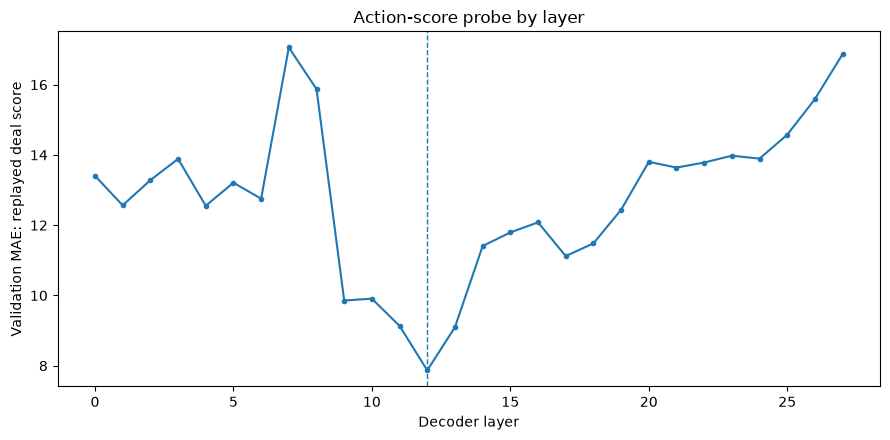

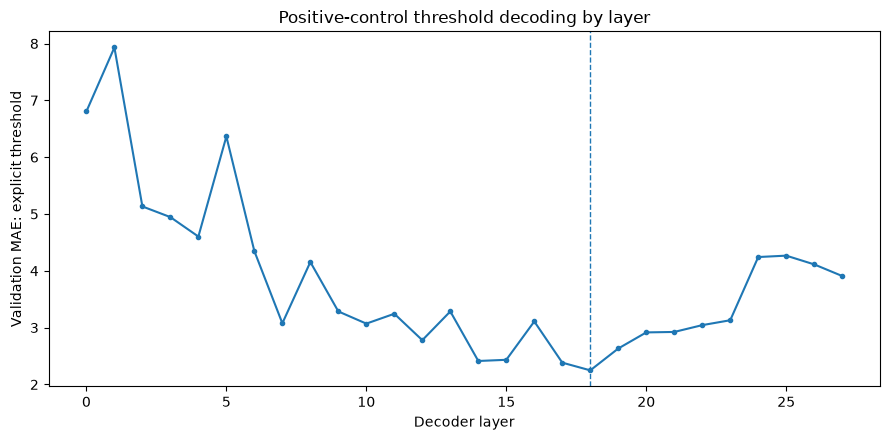

In [16]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(layer_df["layer"], layer_df["val_mae"], marker="o", markersize=3)
ax.axvline(BEST_LAYER, linestyle="--", linewidth=1)
ax.set_xlabel("Decoder layer")
ax.set_ylabel("Validation MAE: replayed deal score")
ax.set_title("Action-score probe by layer")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "figures" / "action_score_probe_by_layer.png", dpi=180)
plt.show()

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(pc_df["layer"], pc_df["val_mae"], marker="o", markersize=3)
ax.axvline(int(pc_selected["layer"]), linestyle="--", linewidth=1)
ax.set_xlabel("Decoder layer")
ax.set_ylabel("Validation MAE: explicit threshold")
ax.set_title("Positive-control threshold decoding by layer")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "figures" / "threshold_positive_control_by_layer.png", dpi=180)
plt.show()

## 14. Final artifact manifest

The pilot result is retained regardless of the sign of `Delta_latent`. A negative or null activation advantage is a valid pilot outcome and must not be repaired by weakening the auditor.


In [17]:
artifact_manifest = {
    "notebook_build": NOTEBOOK_BUILD,
    "run_id": RUN_ID,
    "run_output_dir": str(RUN_OUTPUT_DIR),
    "notebook00_input_run": str(NB00_RUN_DIR),
    "subject_model": SUBJECT_MODEL,
    "upstream_commit": UPSTREAM_COMMIT,
    "upstream_worktree_record": str(worktree_record_path),
    "source_histories": [str(p) for p in trajectory_paths],
    "states_dir": str(DATA_DIR / "states"),
    "first_real_state_replay": str(RESULTS_DIR / "tables" / "first_real_state_replay.json"),
    "actions": str(action_path),
    "auditor": str(auditor_path),
    "activations": str(activation_path),
    "splits": str(DATA_DIR / "derived" / "splits.json"),
    "pilot_summary": str(RESULTS_DIR / "tables" / "pilot_summary.json"),
}
manifest_out = MANIFEST_DIR / "notebook01_manifest.json"
manifest_out.write_text(json.dumps(artifact_manifest, indent=2))

print("\nNotebook 01 complete.")
print(f"Artifact manifest: {manifest_out}")
print(f"Pilot summary: {RESULTS_DIR / 'tables' / 'pilot_summary.json'}")
print(f"Run directory: {RUN_OUTPUT_DIR}")



Notebook 01 complete.
Artifact manifest: /workspace/latent-reservations/notebook_outputs/01_llm_deliberation_pilot/20260813T235230Z/manifests/notebook01_manifest.json
Pilot summary: /workspace/latent-reservations/notebook_outputs/01_llm_deliberation_pilot/20260813T235230Z/results/tables/pilot_summary.json
Run directory: /workspace/latent-reservations/notebook_outputs/01_llm_deliberation_pilot/20260813T235230Z
